# Part 12: Observation scoring for filter predictive distributions

## Overview

Filters in `dynestyx` produce one-step-ahead predictive observation distributions.
Observation scoring lets us evaluate those predictive distributions directly, not just the marginal likelihood.

This notebook has two goals:

- show the smallest possible `dynestyx` pattern for filtering with scoring, and
- show how the same scoring setup can be reused to compare filters and parameter settings.

The three key ingredients are:

- `ObservationScoringConfig(...)`, which says which scores to compute,
- `with Filter(filter_config=filter_config, scoring_config=SCORING_CONFIG):`, which turns scoring on, and
- the resulting per-time score arrays, which are returned as named trace sites.


## TLDR in code

```python
SCORING_CONFIG = ObservationScoringConfig(...)
filter_config = ContinuousTimeEnKFConfig(...)

with Filter(filter_config=filter_config, scoring_config=SCORING_CONFIG):
    samples = Predictive(model, num_samples=1, exclude_deterministic=False)(
        rng_key,
        obs_times=obs_times,
        obs_values=obs_values,
    )
```

That is the whole idea.
Everything else in the notebook is about understanding which scores to ask for and how to interpret the arrays that come back.


In [1]:
import warnings

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from matplotlib.lines import Line2D
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    ScalarDiffusion,
    SDESimulator,
)
from dynestyx.inference.filter_configs import (
    ContinuousTimeEKFConfig,
    ContinuousTimeEnKFConfig,
    ContinuousTimeUKFConfig,
)
from dynestyx.inference.scoring import (
    DawidSebastianiScore,
    EnergyScore,
    GaussianLogProbScore,
    ObservationScoringConfig,
    ObservationWiseCRPSScore,
)

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings(
    "ignore",
    message="A JAX array is being set as static!",
)


## 1. Define the metrics we will use

Section 11.3 of [Machine Learning for Inverse Problems and Data Assimilation](https://arxiv.org/abs/2410.10523) is a good background reference for these scoring rules.
The notation below is adapted to the quantities that `dynestyx` works with at each observation time.

Let `y_t` be the realized observation, let `p_t(y)` be the predictive observation distribution, let `m_t` and `C_t` be its mean and covariance, and let `u_t^{(1)}, \ldots, u_t^{(M)}` be predictive observation samples.

- `GaussianLogProbScore`:
  `dynestyx` records

  $$
  \log p_t(y_t).
  $$

  This is the negative of the paper's negatively oriented logarithmic score, so **higher is better** here.
- `DawidSebastianiScore`:

  $$
  \mathrm{DS}_t = (y_t - m_t)^\top C_t^{-1} (y_t - m_t) + \log \det(C_t).
  $$

  This rewards forecasts that put the realized observation near the predictive mean without making the predictive covariance unnecessarily broad.
  **Lower is better.**
- `ObservationWiseCRPSScore`:
  `dynestyx` applies the scalar Gaussian CRPS to each observation component separately.
  If

  $$
  z_{t,j} = \frac{y_{t,j} - m_{t,j}}{\sigma_{t,j}},
  $$

  then

  $$
  \mathrm{CRPS}_{t,j} = \sigma_{t,j} \left[z_{t,j}\bigl(2\Phi(z_{t,j}) - 1\bigr) + 2\phi(z_{t,j}) - \frac{1}{\sqrt{\pi}}\right].
  $$

  This is a componentwise calibration-and-sharpness score.
  **Lower is better.**
- `EnergyScore(beta)`:

  $$
  \mathrm{ES}_t = \frac{1}{M} \sum_{m=1}^M \lVert u_t^{(m)} - y_t \rVert^{\beta}
  - \frac{1}{2M^2} \sum_{m=1}^M \sum_{m'=1}^M \lVert u_t^{(m)} - u_t^{(m')} \rVert^{\beta}.
  $$

  This is the multivariate sample-based score in the paper.
  It rewards predictive samples that land near the realized observation while penalizing unnecessary spread.
  **Lower is better.**

The `ObservationScoringConfig(...)` arguments used in this notebook are:

- `rules=(...)`: the ordered collection of scores to compute at each observation time.
- Scoring in `dynestyx` always refers to the full predictive observation distribution, including observation noise, so there is no separate target to choose here.
- `sample_source="auto"`: when a score needs predictive samples, let Dynestyx choose the best available source automatically.
- `sample_seed=17`: make any internally synthesized predictive samples reproducible.
- `record_as_numpyro_sites=True` is left implicit, because the default behavior is exactly what we want here: return the score arrays as named sites.

One practical knob is easy to miss:
`GAUSSIAN_SCORE_SAMPLES = 128` controls how many predictive draws Dynestyx uses when a sample-based score such as `EnergyScore` must be synthesized from Gaussian predictive moments.


In [2]:
GAUSSIAN_SCORE_SAMPLES = 128

SCORING_CONFIG = ObservationScoringConfig(
    rules=(
        GaussianLogProbScore(),
        DawidSebastianiScore(),
        ObservationWiseCRPSScore(),
        EnergyScore(beta=1.0, n_samples=GAUSSIAN_SCORE_SAMPLES),
        EnergyScore(beta=1.5, n_samples=GAUSSIAN_SCORE_SAMPLES),
    ),
    sample_source="auto",
    sample_seed=17,
)

SCORING_CONFIG


ObservationScoringConfig(rules=(GaussianLogProbScore(name=None), DawidSebastianiScore(name=None), ObservationWiseCRPSScore(name=None, min_variance=1e-12), EnergyScore(name=None, beta=1.0, n_samples=128, vectorized_pairwise=True), EnergyScore(name=None, beta=1.5, n_samples=128, vectorized_pairwise=True)), record_as_numpyro_sites=True, unsupported='raise', sample_source='auto', sample_seed=17)

The rest of the notebook uses a partially observed Lorenz-63 system.
The next cell defines the model, a small simulation helper, and two tiny plotting helpers.
You can skim it and jump straight to the examples on a first pass.


In [3]:
STATE_DIM = 3
TRUE_RHO = 28.0
OBS_DT = 0.05
OBS_BURN_IN_TIME = 100.0
OBS_FINAL_TIME = 15.0
DIFFUSION_SCALE = 0.1
FILTER_DT0 = 0.005
FULL_SIM_TIMES = jnp.arange(0.0, OBS_BURN_IN_TIME + OBS_FINAL_TIME + 1e-9, OBS_DT)

METRIC_SPECS = [
    ("f_gaussian_log_prob", "Gaussian log-prob", "higher"),
    ("f_dawid_sebastiani", "Dawid-Sebastiani", "lower"),
    ("f_observation_wise_crps", "Observation-wise CRPS", "lower"),
    ("f_energy_score", "Energy score (beta=1.0)", "lower"),
    ("f_energy_score_beta_1_5", "Energy score (beta=1.5)", "lower"),
]
METRIC_SITE_NAMES = tuple(site_name for site_name, _, _ in METRIC_SPECS)


def l63_partial_observation_model(obs_times=None, obs_values=None, predict_times=None):
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0))
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(STATE_DIM),
            covariance_matrix=20.0**2 * jnp.eye(STATE_DIM),
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array(
                [
                    10.0 * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - (8.0 / 3.0) * x[2],
                ]
            ),
            diffusion=ScalarDiffusion(DIFFUSION_SCALE, bm_dim=STATE_DIM),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]),
            R=jnp.array([[1.0]]),
        ),
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


def simulate_dataset(*, rho=TRUE_RHO, key=jr.PRNGKey(0), full_times=FULL_SIM_TIMES):
    predictive = Predictive(
        l63_partial_observation_model,
        params={"rho": jnp.array(rho)},
        num_samples=1,
        exclude_deterministic=False,
    )
    with SDESimulator(source="em_scan"):
        synthetic = predictive(key, predict_times=full_times)

    full_times = synthetic["f_times"][0, 0]
    full_states = synthetic["f_states"][0, 0]
    full_observations = synthetic["f_observations"][0, 0]
    keep_mask = full_times >= OBS_BURN_IN_TIME - 1e-12

    return {
        "times": full_times[keep_mask] - OBS_BURN_IN_TIME,
        "states": full_states[keep_mask],
        "observations": full_observations[keep_mask],
        "burn_in_time": OBS_BURN_IN_TIME,
    }


def plot_dataset(dataset):
    fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True, constrained_layout=True)
    state_labels = ["x1", "x2", "x3"]
    state_colors = ["#1b9e77", "#d95f02", "#7570b3"]

    for state_idx, ax in enumerate(axes):
        ax.plot(
            dataset["times"],
            dataset["states"][:, state_idx],
            color=state_colors[state_idx],
            lw=2.0,
            label=f"true {state_labels[state_idx]}",
        )
        if state_idx == 0:
            ax.scatter(
                dataset["times"],
                dataset["observations"][:, 0],
                s=16,
                color="black",
                alpha=0.65,
                label="observed y",
            )
        ax.set_ylabel(state_labels[state_idx])
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("time")
    fig.suptitle("One partially observed Lorenz-63 trajectory after burn-in", fontsize=14)
    plt.show()


def plot_filtered_example(example_run, dataset):
    filtered_mean = np.asarray(example_run["f_filtered_states_mean"])
    filtered_std = np.sqrt(np.maximum(np.asarray(example_run["f_filtered_states_cov_diag"]), 1e-12))

    fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True, constrained_layout=True)
    state_labels = ["x1", "x2", "x3"]
    state_colors = ["#1b9e77", "#d95f02", "#7570b3"]

    for state_idx, ax in enumerate(axes):
        ax.plot(
            dataset["times"],
            dataset["states"][:, state_idx],
            color=state_colors[state_idx],
            lw=1.8,
            label=f"true {state_labels[state_idx]}",
        )
        ax.plot(
            dataset["times"],
            filtered_mean[:, state_idx],
            color="#1f78b4",
            lw=2.0,
            label="filtered mean",
        )
        ax.fill_between(
            dataset["times"],
            filtered_mean[:, state_idx] - 2.0 * filtered_std[:, state_idx],
            filtered_mean[:, state_idx] + 2.0 * filtered_std[:, state_idx],
            color="#a6cee3",
            alpha=0.5,
            label="filtered mean ± 2 std",
        )
        if state_idx == 0:
            ax.scatter(
                dataset["times"],
                dataset["observations"][:, 0],
                s=14,
                color="black",
                alpha=0.5,
                label="observed y",
            )
        ax.set_ylabel(state_labels[state_idx])
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("time")
    fig.suptitle("Example 1: filtered means and marginal uncertainty", fontsize=14)
    plt.show()


def describe_example_run(example_run):
    score_site_names = {site_name for site_name, _, _ in METRIC_SPECS}
    other_site_names = sorted(name for name in example_run if name not in score_site_names)

    print("Returned non-score sites:")
    for name in other_site_names:
        print(f"  {name:>32s}: {tuple(np.asarray(example_run[name]).shape)}")

    print("\nReturned score sites:")
    for site_name, label, objective in METRIC_SPECS:
        arr = np.asarray(example_run[site_name])
        print(f"  {site_name:>32s}: {tuple(arr.shape)}  ({objective} better)")

    print("\nTime-averaged scores:")
    for site_name, label, objective in METRIC_SPECS:
        value = float(np.asarray(example_run[site_name]).mean())
        print(f"  {label:28s} ({objective:6s} better): {value:.4f}")


## Generate synthetic data

We simulate one noisy, partially observed trajectory and keep only the post-burn-in segment.
The code here is intentionally minimal; the important thing to notice is the data we will condition on.


retained observations: 301
observation shape per time step: (1,)


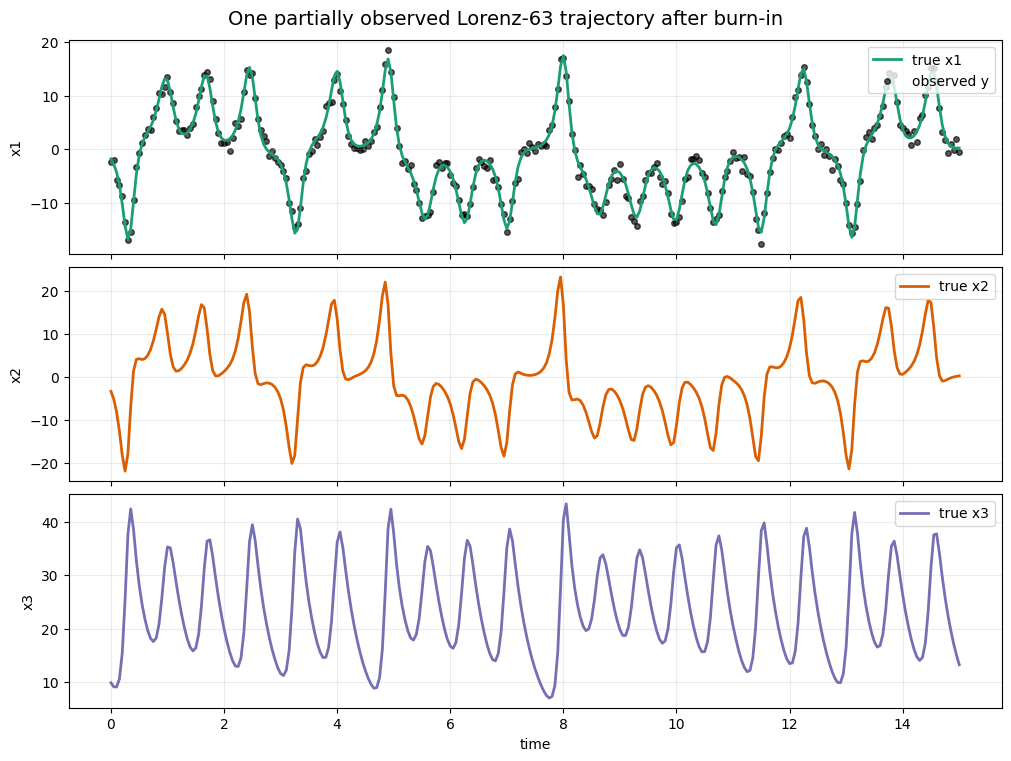

In [4]:
dataset = simulate_dataset()
obs_times = dataset["times"]
obs_values = dataset["observations"]

print(f"retained observations: {obs_values.shape[0]}")
print(f"observation shape per time step: {obs_values.shape[1:]}")
plot_dataset(dataset)


## Example 1: filter once with scoring

This example is intentionally small.
The only thing that is new, relative to an ordinary filtering call, is `scoring_config=SCORING_CONFIG`.

We also ask the filter to record `f_filtered_states_mean` and `f_filtered_states_cov_diag` so we can visualize the filtered state trajectories alongside their uncertainty.


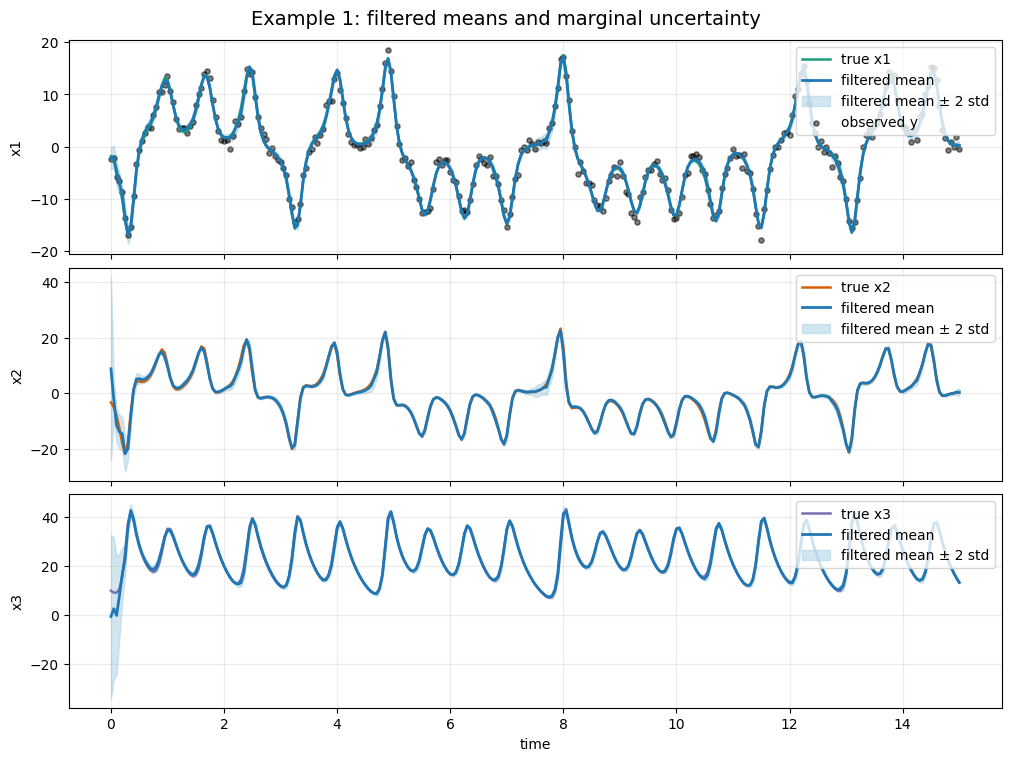

Returned non-score sites:
             f_filtered_states_cov: (301, 3, 3)
        f_filtered_states_cov_diag: (301, 3)
            f_filtered_states_mean: (301, 3)
         f_marginal_log_likelihood: (0,)
                 f_marginal_loglik: ()

Returned score sites:
               f_gaussian_log_prob: (301, 1)  (higher better)
                f_dawid_sebastiani: (301, 1)  (lower better)
           f_observation_wise_crps: (301, 1)  (lower better)
                    f_energy_score: (301, 1)  (lower better)
           f_energy_score_beta_1_5: (301, 1)  (lower better)

Time-averaged scores:
  Gaussian log-prob            (higher better): -1.4916
  Dawid-Sebastiani             (lower  better): 1.1454
  Observation-wise CRPS        (lower  better): 0.6240
  Energy score (beta=1.0)      (lower  better): 0.6279
  Energy score (beta=1.5)      (lower  better): 0.8598


In [5]:
example_filter_config = ContinuousTimeEnKFConfig(
    n_particles=30,
    crn_seed=jr.PRNGKey(0),
    diffeqsolve_dt0=FILTER_DT0,
    record_filtered_states_mean=True,
    record_filtered_states_cov_diag=True,
    warn=False,
)

with Filter(filter_config=example_filter_config, scoring_config=SCORING_CONFIG):
    example_samples = Predictive(
        l63_partial_observation_model,
        params={"rho": jnp.array(TRUE_RHO)},
        num_samples=1,
        exclude_deterministic=False,
    )(
        jr.PRNGKey(123),
        obs_times=obs_times,
        obs_values=obs_values,
    )

example_run = {
    name: jnp.asarray(value[0])
    for name, value in example_samples.items()
    if name.startswith("f_")
}

plot_filtered_example(example_run, dataset)
describe_example_run(example_run)


The main takeaway from Example 1 is that scoring shows up as ordinary trace sites.
In this run, the new score-related sites are the `f_gaussian_log_prob`, `f_dawid_sebastiani`, `f_observation_wise_crps`, and `f_energy_score...` arrays.

Because we did **not** ask for predictive observation summary recording, there are no `f_predicted_observations_*` sites here.
That is a separate feature from scoring.


## Example 2: use scoring to compare filters

Now we reuse the same `SCORING_CONFIG` to compare filters more systematically.
This is the part of the notebook where the larger helper block is worth having.

The next cell defines:

- filter constructors,
- a scored-filter runner,
- aggregation helpers, and
- the `scan`-based evaluation routine we use when `n_particles` changes backend array shapes.


In [9]:
N_PARTICLES_VALUES = [10, 20, 30, 40, 50, 75, 100, 150, 200, 250, 300]
PROFILE_N_PARTICLES_VALUES = [10, 30, 100]
CRN_SEED_INTS = list(range(6))
RHO_GRID = jnp.linspace(24.0, 32.0, 9)
BASELINE_METHOD_SPECS = [
    ("ekf_first", "EKF (1st-order)", "#e66101"),
    ("ekf_second", "EKF (2nd-order)", "#fdb863"),
    ("ukf", "UKF", "#1b9e77"),
]
ENKF_MEDIAN_COLOR = "#2171b5"
ALL_PARTICLE_VALUES = tuple(sorted(set(N_PARTICLES_VALUES + PROFILE_N_PARTICLES_VALUES)))
ALL_PARTICLE_INDEX = {value: idx for idx, value in enumerate(ALL_PARTICLE_VALUES)}


def make_enkf_color_map(particle_values):
    shades = np.linspace(0.4, 0.9, len(particle_values))
    return {
        int(n_particles): plt.cm.Blues(shade)
        for n_particles, shade in zip(particle_values, shades, strict=True)
    }


def make_enkf_config(n_particles: int, crn_seed_int: int) -> ContinuousTimeEnKFConfig:
    return ContinuousTimeEnKFConfig(
        n_particles=n_particles,
        crn_seed=jr.PRNGKey(crn_seed_int),
        diffeqsolve_dt0=FILTER_DT0,
        warn=False,
    )


def make_gaussian_filter_config(method_key: str):
    common_kwargs = dict(diffeqsolve_dt0=FILTER_DT0, warn=False)
    if method_key == "ekf_first":
        return ContinuousTimeEKFConfig(
            filter_state_order="first",
            filter_emission_order="first",
            **common_kwargs,
        )
    if method_key == "ekf_second":
        return ContinuousTimeEKFConfig(
            filter_state_order="second",
            filter_emission_order="second",
            **common_kwargs,
        )
    if method_key == "ukf":
        return ContinuousTimeUKFConfig(
            filter_state_order="first",
            alpha=1.0,
            beta=2,
            kappa=0,
            **common_kwargs,
        )
    raise ValueError(f"Unknown baseline method: {method_key}")


def run_scored_filter(*, rho: float, filter_config, obs_times, obs_values):
    with Filter(filter_config=filter_config, scoring_config=SCORING_CONFIG):
        samples = Predictive(
            l63_partial_observation_model,
            params={"rho": jnp.array(rho)},
            num_samples=1,
            exclude_deterministic=False,
        )(
            jr.PRNGKey(123),
            obs_times=obs_times,
            obs_values=obs_values,
        )
    return {
        name: jnp.asarray(value[0])
        for name, value in samples.items()
        if name.startswith("f_")
    }


def run_scored_enkf(*, rho: float, n_particles: int, crn_seed_int: int, obs_times, obs_values):
    return run_scored_filter(
        rho=rho,
        filter_config=make_enkf_config(n_particles, crn_seed_int),
        obs_times=obs_times,
        obs_values=obs_values,
    )


def run_scored_baseline(*, rho: float, method_key: str, obs_times, obs_values):
    return run_scored_filter(
        rho=rho,
        filter_config=make_gaussian_filter_config(method_key),
        obs_times=obs_times,
        obs_values=obs_values,
    )


def evaluate_metric_vector(*, rho: float, n_particles: int, crn_seed_int: int, obs_times, obs_values):
    run_sites = run_scored_enkf(
        rho=rho,
        n_particles=n_particles,
        crn_seed_int=crn_seed_int,
        obs_times=obs_times,
        obs_values=obs_values,
    )
    return jnp.asarray(
        [jnp.mean(run_sites[site_name]) for site_name in METRIC_SITE_NAMES],
        dtype=jnp.float64,
    )


def evaluate_baseline_metric_vector(*, rho: float, method_key: str, obs_times, obs_values):
    run_sites = run_scored_baseline(
        rho=rho,
        method_key=method_key,
        obs_times=obs_times,
        obs_values=obs_values,
    )
    return np.asarray(
        [float(jnp.mean(run_sites[site_name])) for site_name in METRIC_SITE_NAMES],
        dtype=float,
    )


def evaluate_baseline_metric_grid(*, rho_values, obs_times, obs_values):
    rho_values = np.asarray(rho_values, dtype=float)
    results = {}
    for method_key, _, _ in BASELINE_METHOD_SPECS:
        rows = [
            evaluate_baseline_metric_vector(
                rho=float(rho),
                method_key=method_key,
                obs_times=obs_times,
                obs_values=obs_values,
            )
            for rho in rho_values
        ]
        results[method_key] = np.vstack(rows)
    return results


def _coerce_seed_values(seed_values=None):
    if seed_values is None:
        seed_values = CRN_SEED_INTS
    return jnp.asarray(seed_values, dtype=jnp.int32)


def _particle_metric_branches(obs_times, obs_values):
    return [
        (
            lambda operand, n_particles=n_particles: evaluate_metric_vector(
                rho=operand[0],
                n_particles=n_particles,
                crn_seed_int=operand[1],
                obs_times=obs_times,
                obs_values=obs_values,
            )
        )
        for n_particles in ALL_PARTICLE_VALUES
    ]


def evaluate_metric_tensor(*, rho_values, particle_values, obs_times, obs_values, seed_values=None):
    rho_values = jnp.atleast_1d(jnp.asarray(rho_values, dtype=jnp.float64))
    seed_values = _coerce_seed_values(seed_values)
    particle_indices = jnp.asarray(
        [ALL_PARTICLE_INDEX[int(value)] for value in particle_values],
        dtype=jnp.int32,
    )
    branches = _particle_metric_branches(obs_times, obs_values)

    def evaluate_fixed_particle(particle_index):
        def per_seed(seed_int):
            def per_rho(rho):
                return jax.lax.switch(particle_index, branches, (rho, seed_int))

            return jax.vmap(per_rho)(rho_values)

        return jax.vmap(per_seed)(seed_values)

    def scan_body(carry, particle_index):
        return carry, evaluate_fixed_particle(particle_index)

    _, metric_tensor = jax.lax.scan(scan_body, None, particle_indices)
    return np.moveaxis(np.asarray(metric_tensor, dtype=float), 0, 2)


def metric_tensor_to_summary_dict(metric_tensor, particle_values):
    summary = {}
    for particle_idx, n_particles in enumerate(particle_values):
        particle_summary = {}
        for metric_idx, site_name in enumerate(METRIC_SITE_NAMES):
            values = metric_tensor[:, particle_idx, metric_idx]
            particle_summary[site_name] = {
                "median": float(np.median(values)),
                "q25": float(np.percentile(values, 25.0)),
                "q75": float(np.percentile(values, 75.0)),
                "q10": float(np.percentile(values, 10.0)),
                "q90": float(np.percentile(values, 90.0)),
            }
        summary[int(n_particles)] = particle_summary
    return summary


def profile_tensor_to_summary_dict(metric_tensor, rho_values, particle_values):
    summary = {}
    for particle_idx, n_particles in enumerate(particle_values):
        particle_summary = {}
        for metric_idx, site_name in enumerate(METRIC_SITE_NAMES):
            particle_summary[site_name] = {
                "median": [
                    float(np.median(metric_tensor[:, rho_idx, particle_idx, metric_idx]))
                    for rho_idx in range(len(rho_values))
                ],
                "q10": [
                    float(np.percentile(metric_tensor[:, rho_idx, particle_idx, metric_idx], 10.0))
                    for rho_idx in range(len(rho_values))
                ],
                "q90": [
                    float(np.percentile(metric_tensor[:, rho_idx, particle_idx, metric_idx], 90.0))
                    for rho_idx in range(len(rho_values))
                ],
            }
        summary[int(n_particles)] = particle_summary
    return summary


def best_rho(rho_values, metric_center_values, objective: str) -> tuple[float, float]:
    metric_center_values = np.asarray(metric_center_values)
    idx = int(np.argmax(metric_center_values)) if objective == "higher" else int(np.argmin(metric_center_values))
    return float(rho_values[idx]), float(metric_center_values[idx])


## 2a. Comparing at the known true model

We now keep `rho` fixed at its true value and ask how the scores change across EnKF ensemble sizes.
We also include EKF and UKF baselines.


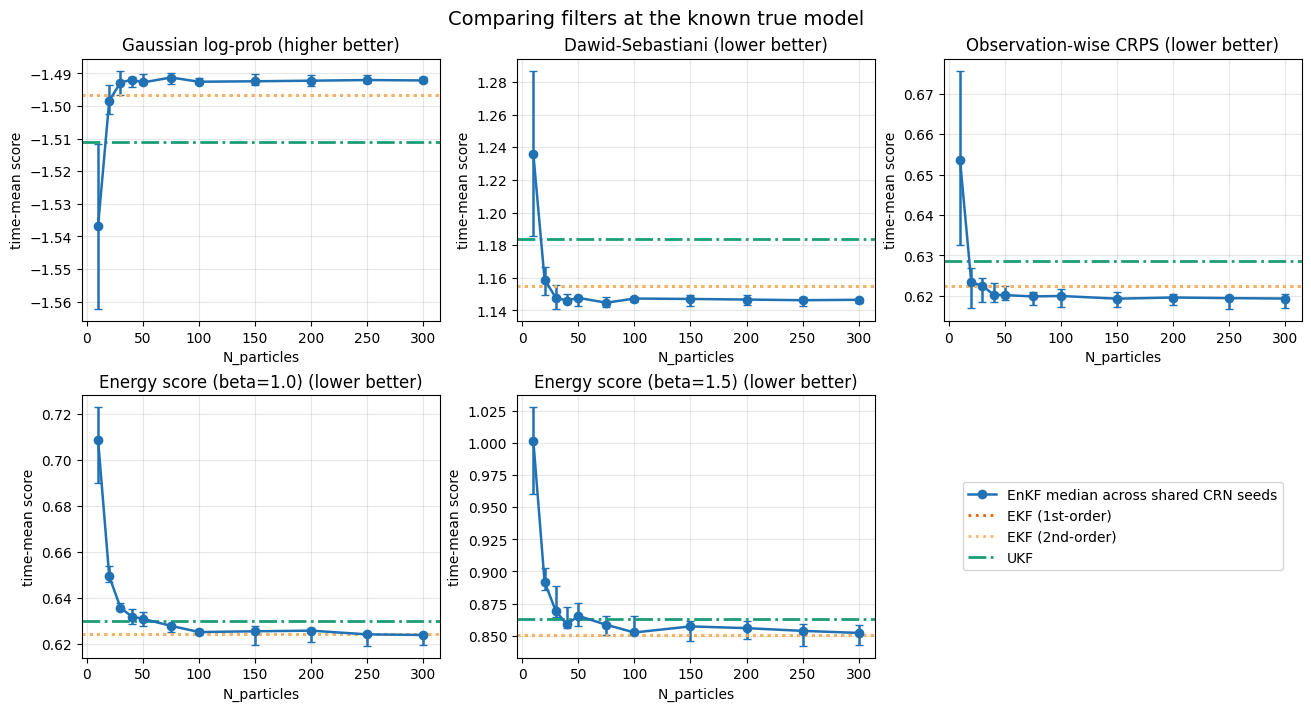

In [10]:
known_metric_tensor = evaluate_metric_tensor(
    rho_values=jnp.asarray([TRUE_RHO]),
    particle_values=N_PARTICLES_VALUES,
    obs_times=obs_times,
    obs_values=obs_values,
)[:, 0]
known_parameter_results = metric_tensor_to_summary_dict(
    known_metric_tensor,
    N_PARTICLES_VALUES,
)
baseline_true_metric_grid = evaluate_baseline_metric_grid(
    rho_values=[TRUE_RHO],
    obs_times=obs_times,
    obs_values=obs_values,
)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
axes = axes.ravel()
for ax, (site_name, label, objective) in zip(axes[:-1], METRIC_SPECS, strict=True):
    metric_idx = METRIC_SITE_NAMES.index(site_name)
    medians = [known_parameter_results[n_particles][site_name]["median"] for n_particles in N_PARTICLES_VALUES]
    q25s = [known_parameter_results[n_particles][site_name]["q25"] for n_particles in N_PARTICLES_VALUES]
    q75s = [known_parameter_results[n_particles][site_name]["q75"] for n_particles in N_PARTICLES_VALUES]
    yerr = np.vstack([
        np.asarray(medians) - np.asarray(q25s),
        np.asarray(q75s) - np.asarray(medians),
    ])
    ax.errorbar(
        N_PARTICLES_VALUES,
        medians,
        yerr=yerr,
        marker="o",
        lw=1.8,
        capsize=3,
        color=ENKF_MEDIAN_COLOR,
    )
    for method_key, baseline_label, color in BASELINE_METHOD_SPECS:
        baseline_value = baseline_true_metric_grid[method_key][0, metric_idx]
        ax.axhline(
            baseline_value,
            color=color,
            linestyle=":" if method_key != "ukf" else "-.",
            lw=2.0,
        )
    ax.set_xlabel("N_particles")
    ax.set_ylabel("time-mean score")
    ax.set_title(f"{label} ({objective} better)")
    ax.grid(alpha=0.3)

legend_handles = [
    Line2D([0], [0], color=ENKF_MEDIAN_COLOR, marker="o", lw=1.8, label="EnKF median across shared CRN seeds"),
]
legend_handles.extend(
    Line2D(
        [0],
        [0],
        color=color,
        linestyle=":" if method_key != "ukf" else "-.",
        lw=2.0,
        label=label,
    )
    for method_key, label, color in BASELINE_METHOD_SPECS
)
axes[-1].axis("off")
axes[-1].legend(handles=legend_handles, loc="center")
fig.suptitle("Comparing filters at the known true model", fontsize=14)
plt.show()


## 2b. Comparing across a profile of unknown parameters

Finally, we treat the scores as parameter-sensitive diagnostics.
Here we profile them over a small grid of `rho` values and compare several EnKF ensemble sizes against EKF and UKF baselines.


Best rho values for EnKF N_particles=10:
  Gaussian log-prob            -> rho=28.00, median score=-1.5368
  Dawid-Sebastiani             -> rho=28.00, median score=1.2358
  Observation-wise CRPS        -> rho=28.00, median score=0.6536
  Energy score (beta=1.0)      -> rho=28.00, median score=0.7089
  Energy score (beta=1.5)      -> rho=28.00, median score=1.0015

Best rho values for EnKF N_particles=30:
  Gaussian log-prob            -> rho=28.00, median score=-1.4928
  Dawid-Sebastiani             -> rho=28.00, median score=1.1478
  Observation-wise CRPS        -> rho=28.00, median score=0.6225
  Energy score (beta=1.0)      -> rho=28.00, median score=0.6358
  Energy score (beta=1.5)      -> rho=28.00, median score=0.8692

Best rho values for EnKF N_particles=100:
  Gaussian log-prob            -> rho=28.00, median score=-1.4926
  Dawid-Sebastiani             -> rho=28.00, median score=1.1473
  Observation-wise CRPS        -> rho=28.00, median score=0.6200
  Energy score (beta=1.0) 

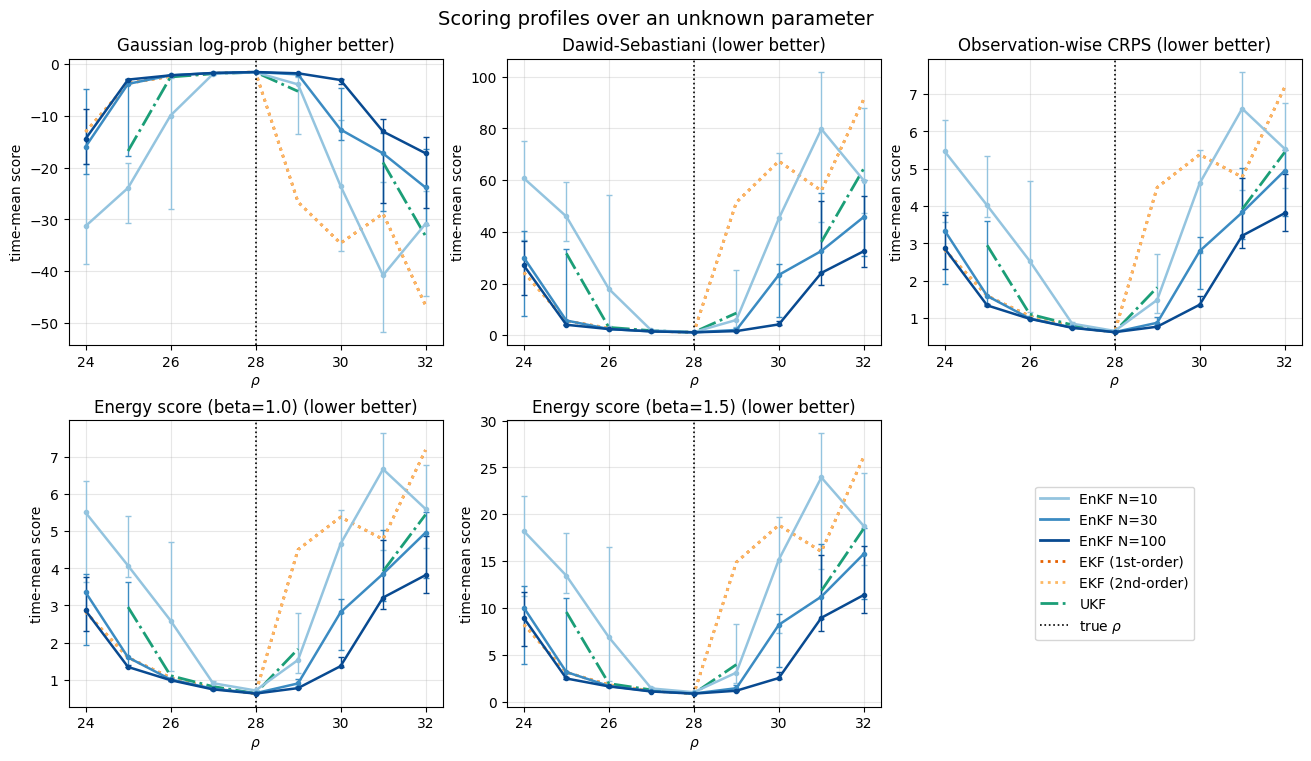

In [8]:
profile_metric_tensor = evaluate_metric_tensor(
    rho_values=RHO_GRID,
    particle_values=PROFILE_N_PARTICLES_VALUES,
    obs_times=obs_times,
    obs_values=obs_values,
)
profile_results = profile_tensor_to_summary_dict(
    profile_metric_tensor,
    RHO_GRID,
    PROFILE_N_PARTICLES_VALUES,
)
baseline_profile_metric_grid = evaluate_baseline_metric_grid(
    rho_values=RHO_GRID,
    obs_times=obs_times,
    obs_values=obs_values,
)

for n_particles in PROFILE_N_PARTICLES_VALUES:
    print(f"Best rho values for EnKF N_particles={n_particles}:")
    for site_name, label, objective in METRIC_SPECS:
        rho_star, metric_star = best_rho(
            RHO_GRID,
            profile_results[n_particles][site_name]["median"],
            objective,
        )
        print(f"  {label:28s} -> rho={rho_star:5.2f}, median score={metric_star:.4f}")
    print()

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), constrained_layout=True)
axes = axes.ravel()
profile_colors = make_enkf_color_map(PROFILE_N_PARTICLES_VALUES)

for ax, (site_name, label, objective) in zip(axes[:-1], METRIC_SPECS, strict=True):
    metric_idx = METRIC_SITE_NAMES.index(site_name)
    for particle_idx, n_particles in enumerate(PROFILE_N_PARTICLES_VALUES):
        medians = profile_results[n_particles][site_name]["median"]
        q10s = profile_results[n_particles][site_name]["q10"]
        q90s = profile_results[n_particles][site_name]["q90"]
        yerr = np.vstack([
            np.asarray(medians) - np.asarray(q10s),
            np.asarray(q90s) - np.asarray(medians),
        ])
        ax.errorbar(
            RHO_GRID,
            medians,
            yerr=yerr,
            color=profile_colors[n_particles],
            lw=1.8,
            elinewidth=1.0,
            capsize=2.5,
            marker="o",
            markersize=3.0,
            label=f"EnKF N={n_particles}",
        )
    for method_key, baseline_label, color in BASELINE_METHOD_SPECS:
        ax.plot(
            RHO_GRID,
            baseline_profile_metric_grid[method_key][:, metric_idx],
            color=color,
            linestyle=":" if method_key != "ukf" else "-.",
            lw=2.0,
            label=baseline_label,
        )
    ax.axvline(TRUE_RHO, color="black", linestyle=":", lw=1.2)
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel("time-mean score")
    ax.set_title(f"{label} ({objective} better)")
    ax.grid(alpha=0.3)

legend_handles = [
    Line2D([0], [0], color=profile_colors[n_particles], lw=2.0, label=f"EnKF N={n_particles}")
    for n_particles in PROFILE_N_PARTICLES_VALUES
]
legend_handles.extend(
    Line2D([0], [0], color=color, lw=2.0, linestyle=":" if method_key != "ukf" else "-.", label=label)
    for method_key, label, color in BASELINE_METHOD_SPECS
)
legend_handles.append(
    Line2D([0], [0], color="black", lw=1.2, linestyle=":", label=r"true $\rho$")
)
axes[-1].axis("off")
axes[-1].legend(handles=legend_handles, loc="center")
fig.suptitle("Scoring profiles over an unknown parameter", fontsize=14)
plt.show()


## Takeaways

- The core Dynestyx pattern is small: define `SCORING_CONFIG`, then pass it into `Filter(..., scoring_config=SCORING_CONFIG)`.
- The score arrays are ordinary trace sites, so they can be inspected directly or aggregated later.
- Different scores emphasize different aspects of predictive quality, so it is worth looking at more than one.
- Once the scoring configuration is in place, the same API supports both one-off diagnostics and larger filter-comparison studies.

**Previous:** [Part 11c — Missing observations in HMMs](../11c_missing_observations_hmms/)
